<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Bubble Plots**


Estimated time needed: **30** minutes


In this lab, you will focus on visualizing data.

The dataset will be directly loaded into pandas for analysis and visualization.

You will use various visualization techniques to explore the data and uncover key trends.


## Objectives


In this lab, you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two data features.

-   Visualize composition of data.

-   Visualize comparison of data.


#### Setup: Working with the Database
**Install and import the needed libraries**


In [1]:
!pip install pandas 
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [2]:
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
df = pd.read_csv("survey-data.csv")

# Preparar colunas numéricas
age_map = {
    'Under 18 years old': 17, '18-24 years old': 21,
    '25-34 years old': 29, '35-44 years old': 39,
    '45-54 years old': 49, '55-64 years old': 59,
    '65 years or older': 65
}
df['Age_num'] = df['Age'].map(age_map)
df['JobSat'] = pd.to_numeric(df['JobSat'], errors='coerce')
df['ConvertedCompYearly'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')

print("Carregado:", df.shape)


--2026-04-04 23:40:46--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
connected. to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... 
200 OKequest sent, awaiting response... 
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  41.4MB/s    in 3.7s    

2026-04-04 23:40:50 (41.4 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]

Carregado: (65437, 115)


### Task 1: Exploring Data Distributions Using Bubble Plots


#### 1. Bubble Plot for Age vs. Frequency of Participation


- Visualize the relationship between respondents’ age and their participation frequency (`SOPartFreq`) using a bubble plot.

- Use the size of the bubbles to represent their job satisfaction (`JobSat`).


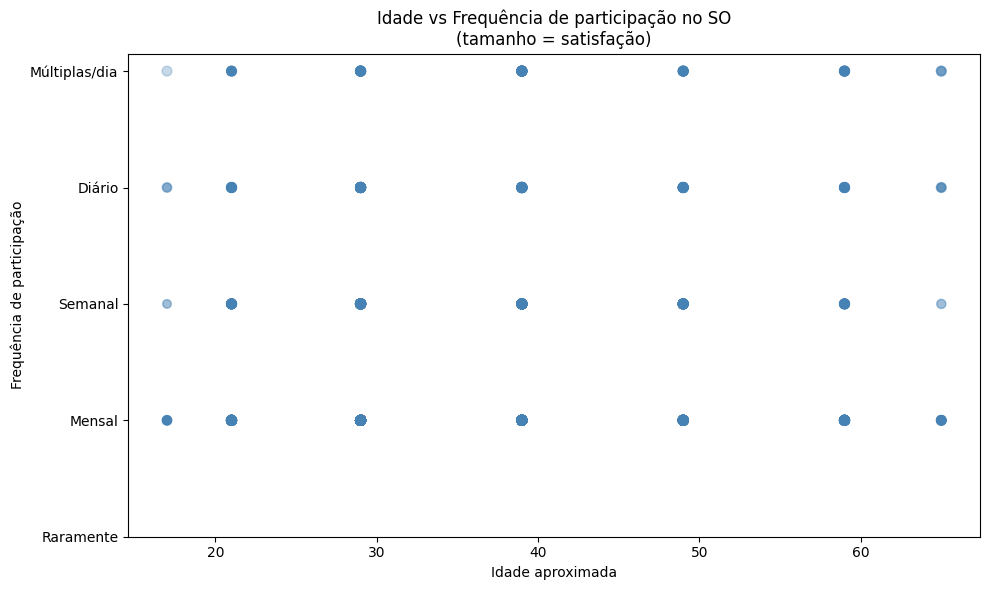

In [3]:
# Mapear SOPartFreq para número
freq_map = {
    'Multiple times per day': 5,
    'Daily or almost daily': 4,
    'A few times per week': 3,
    'A few times per month or weekly': 2,
    'Less than once per month or rarely': 1
}
df['SOPartFreq_num'] = df['SOPartFreq'].map(freq_map)

df_plot = df[['Age_num', 'SOPartFreq_num', 'JobSat']].dropna()

plt.figure(figsize=(10, 6))
plt.scatter(
    df_plot['Age_num'],
    df_plot['SOPartFreq_num'],
    s=df_plot['JobSat'] * 5,
    alpha=0.3,
    color='steelblue'
)
plt.title('Idade vs Frequência de participação no SO\n(tamanho = satisfação)')
plt.xlabel('Idade aproximada')
plt.ylabel('Frequência de participação')
plt.yticks([1,2,3,4,5], ['Raramente','Mensal','Semanal','Diário','Múltiplas/dia'])
plt.tight_layout()
plt.show()

#### 2. Bubble Plot for Compensation vs. Job Satisfaction


-Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSat`).

- Use the size of the bubbles to represent respondents’ age.


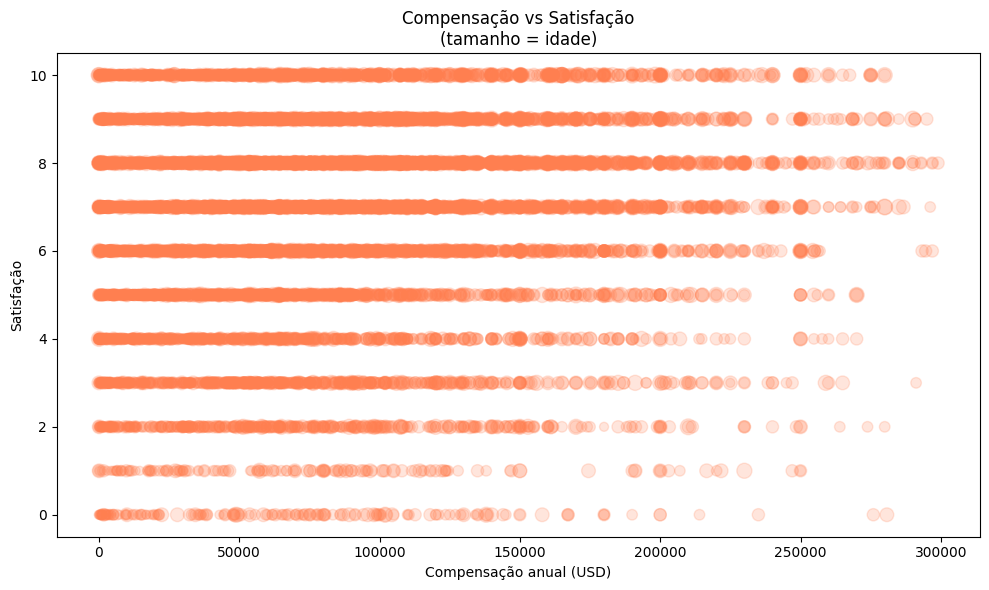

In [4]:
df_plot = df[['ConvertedCompYearly', 'JobSat', 'Age_num']].dropna()
df_plot = df_plot[df_plot['ConvertedCompYearly'] < 300000]

plt.figure(figsize=(10, 6))
plt.scatter(
    df_plot['ConvertedCompYearly'],
    df_plot['JobSat'],
    s=df_plot['Age_num'] * 2,
    alpha=0.2,
    color='coral'
)
plt.title('Compensação vs Satisfação\n(tamanho = idade)')
plt.xlabel('Compensação anual (USD)')
plt.ylabel('Satisfação')
plt.tight_layout()
plt.show()

### Task 2: Analyzing Relationships Using Bubble Plots


#### 1. Bubble Plot of Technology Preferences by Age

- Visualize the popularity of programming languages respondents have worked with (`LanguageHaveWorkedWith`) across age groups.

- Use bubble size to represent the frequency of each language.



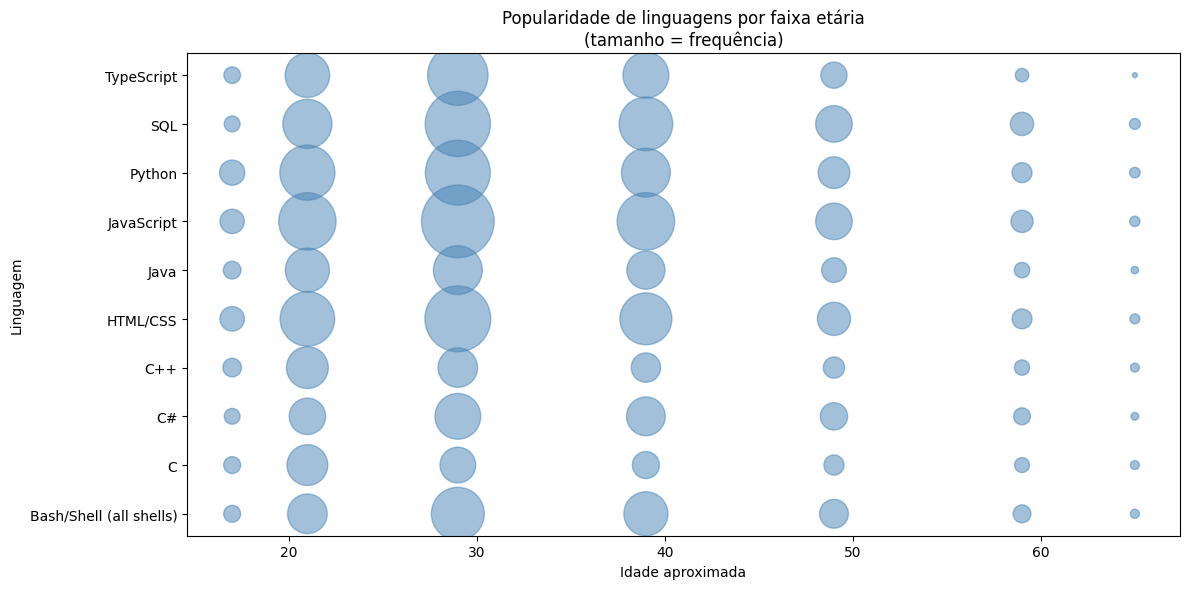

In [5]:
df_lang = df[['LanguageHaveWorkedWith', 'Age_num']].dropna()
df_lang = df_lang.assign(
    Language=df_lang['LanguageHaveWorkedWith'].str.split(';')
).explode('Language')
df_lang['Language'] = df_lang['Language'].str.strip()

top_langs = df_lang['Language'].value_counts().head(10).index
df_lang = df_lang[df_lang['Language'].isin(top_langs)]

lang_age = df_lang.groupby(['Language', 'Age_num']).size().reset_index(name='Count')

plt.figure(figsize=(12, 6))
plt.scatter(
    lang_age['Age_num'],
    lang_age['Language'],
    s=lang_age['Count'] / 5,
    alpha=0.5,
    color='steelblue'
)
plt.title('Popularidade de linguagens por faixa etária\n(tamanho = frequência)')
plt.xlabel('Idade aproximada')
plt.ylabel('Linguagem')
plt.tight_layout()
plt.show()

#### 2. Bubble Plot for Preferred Databases vs. Job Satisfaction

- Explore the relationship between preferred databases (`DatabaseWantToWorkWith`) and job satisfaction.

- Use bubble size to indicate the number of respondents for each database.


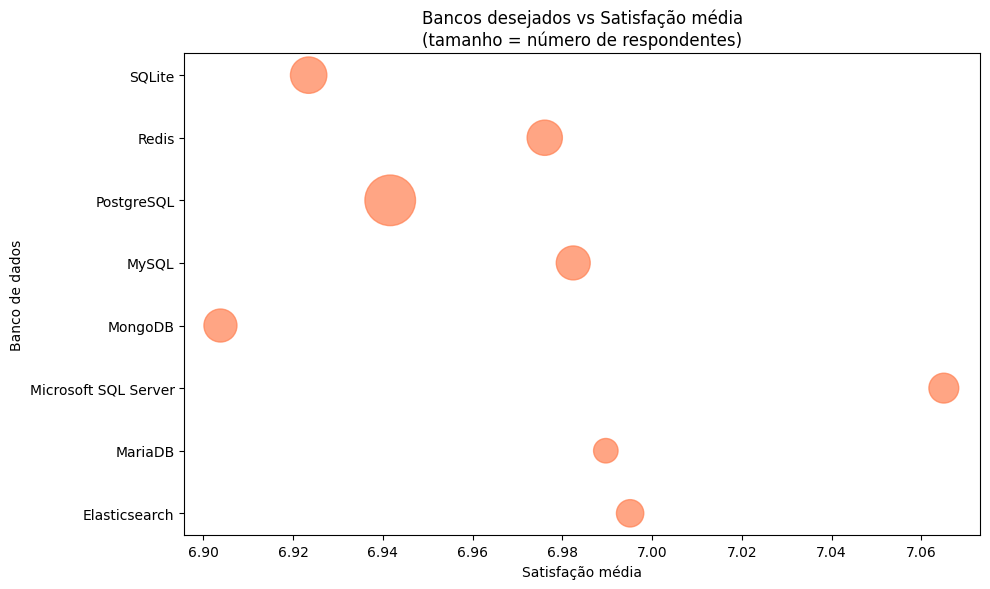

In [6]:
df_db = df[['DatabaseWantToWorkWith', 'JobSat']].dropna()
df_db = df_db.assign(
    Database=df_db['DatabaseWantToWorkWith'].str.split(';')
).explode('Database')
df_db['Database'] = df_db['Database'].str.strip()

top_dbs = df_db['Database'].value_counts().head(8).index
df_db = df_db[df_db['Database'].isin(top_dbs)]

db_sat = df_db.groupby('Database').agg(
    MeanSat=('JobSat', 'mean'),
    Count=('JobSat', 'count')
).reset_index()

plt.figure(figsize=(10, 6))
plt.scatter(
    db_sat['MeanSat'],
    db_sat['Database'],
    s=db_sat['Count'] / 10,
    alpha=0.7,
    color='coral'
)
plt.title('Bancos desejados vs Satisfação média\n(tamanho = número de respondentes)')
plt.xlabel('Satisfação média')
plt.ylabel('Banco de dados')
plt.tight_layout()
plt.show()

### Task 3: Comparing Data Using Bubble Plots


#### 1. Bubble Plot for Compensation Across Developer Roles

- Visualize compensation (`ConvertedCompYearly`) across different developer roles (`DevType`).

- Use bubble size to represent job satisfaction.


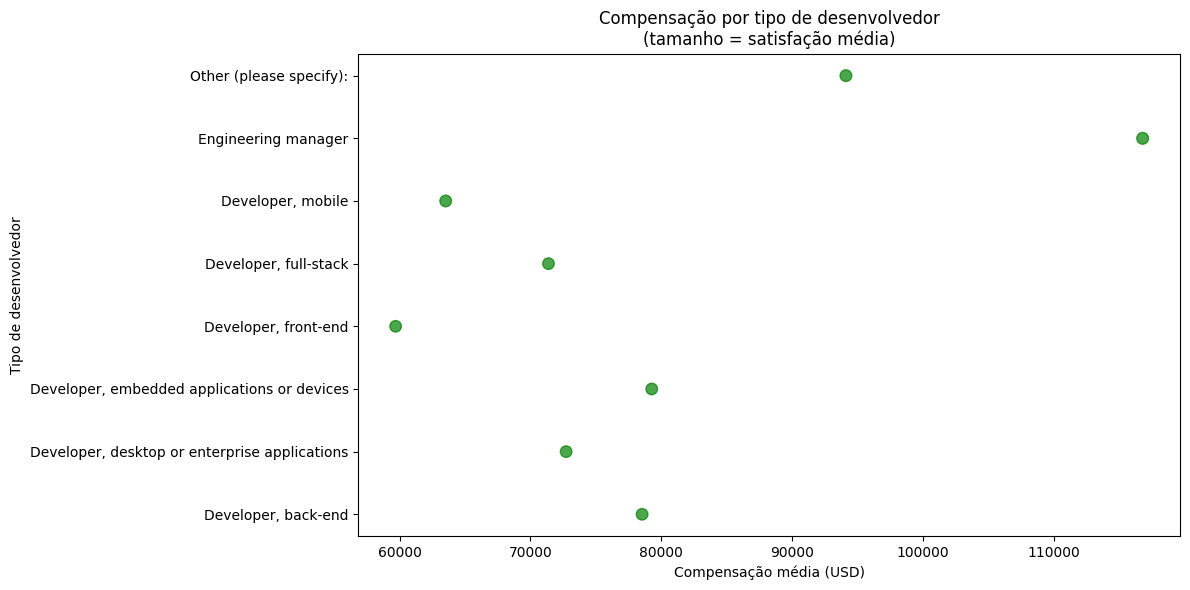

In [7]:
df_dev = df[['DevType', 'ConvertedCompYearly', 'JobSat']].dropna()
df_dev = df_dev[df_dev['ConvertedCompYearly'] < 300000]
df_dev = df_dev.assign(
    Dev=df_dev['DevType'].str.split(';')
).explode('Dev')
df_dev['Dev'] = df_dev['Dev'].str.strip()

top_devs = df_dev['Dev'].value_counts().head(8).index
df_dev = df_dev[df_dev['Dev'].isin(top_devs)]

dev_stats = df_dev.groupby('Dev').agg(
    MeanComp=('ConvertedCompYearly', 'mean'),
    MeanSat=('JobSat', 'mean'),
    Count=('JobSat', 'count')
).reset_index()

plt.figure(figsize=(12, 6))
plt.scatter(
    dev_stats['MeanComp'],
    dev_stats['Dev'],
    s=dev_stats['MeanSat'] * 10,
    alpha=0.7,
    color='green'
)
plt.title('Compensação por tipo de desenvolvedor\n(tamanho = satisfação média)')
plt.xlabel('Compensação média (USD)')
plt.ylabel('Tipo de desenvolvedor')
plt.tight_layout()
plt.show()

#### 2. Bubble Plot for Collaboration Tools by Age

- Visualize the relationship between the collaboration tools used (`NEWCollabToolsHaveWorkedWith`) and age groups.

- Use bubble size to represent the frequency of tool usage.


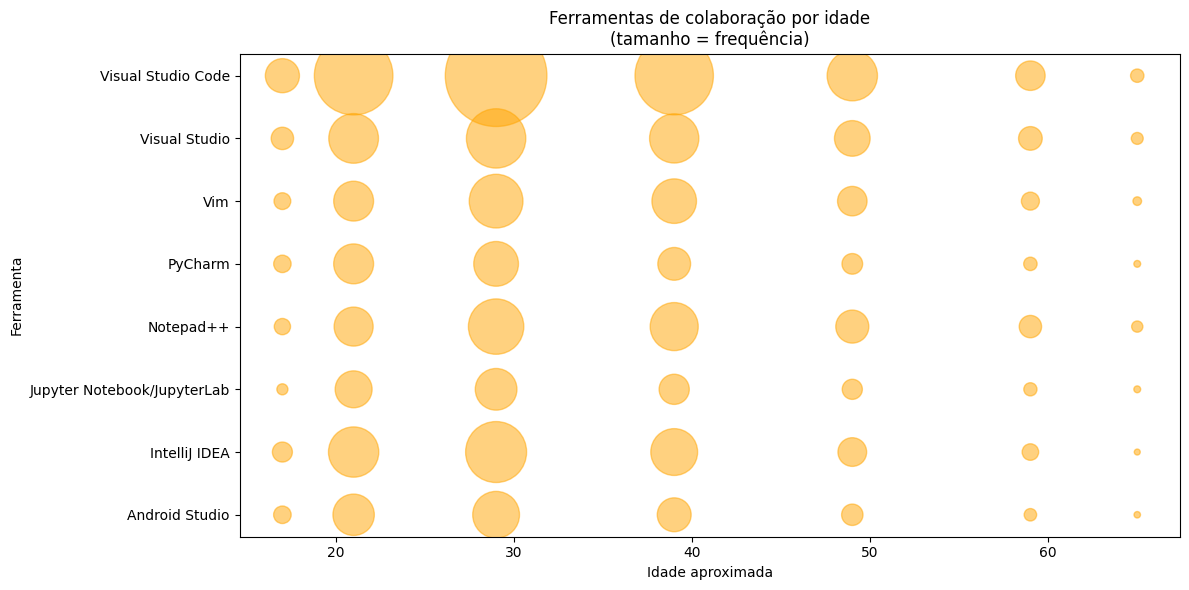

In [8]:
df_tools = df[['NEWCollabToolsHaveWorkedWith', 'Age_num']].dropna()
df_tools = df_tools.assign(
    Tool=df_tools['NEWCollabToolsHaveWorkedWith'].str.split(';')
).explode('Tool')
df_tools['Tool'] = df_tools['Tool'].str.strip()

top_tools = df_tools['Tool'].value_counts().head(8).index
df_tools = df_tools[df_tools['Tool'].isin(top_tools)]

tool_age = df_tools.groupby(['Tool', 'Age_num']).size().reset_index(name='Count')

plt.figure(figsize=(12, 6))
plt.scatter(
    tool_age['Age_num'],
    tool_age['Tool'],
    s=tool_age['Count'] / 3,
    alpha=0.5,
    color='orange'
)
plt.title('Ferramentas de colaboração por idade\n(tamanho = frequência)')
plt.xlabel('Idade aproximada')
plt.ylabel('Ferramenta')
plt.tight_layout()
plt.show()

### Task 4: Visualizing Technology Trends Using Bubble Plots


#### 1. Bubble Plot for Preferred Web Frameworks vs. Job Satisfaction

- Explore the relationship between preferred web frameworks (`WebframeWantToWorkWith`) and job satisfaction.

- Use bubble size to represent the number of respondents.



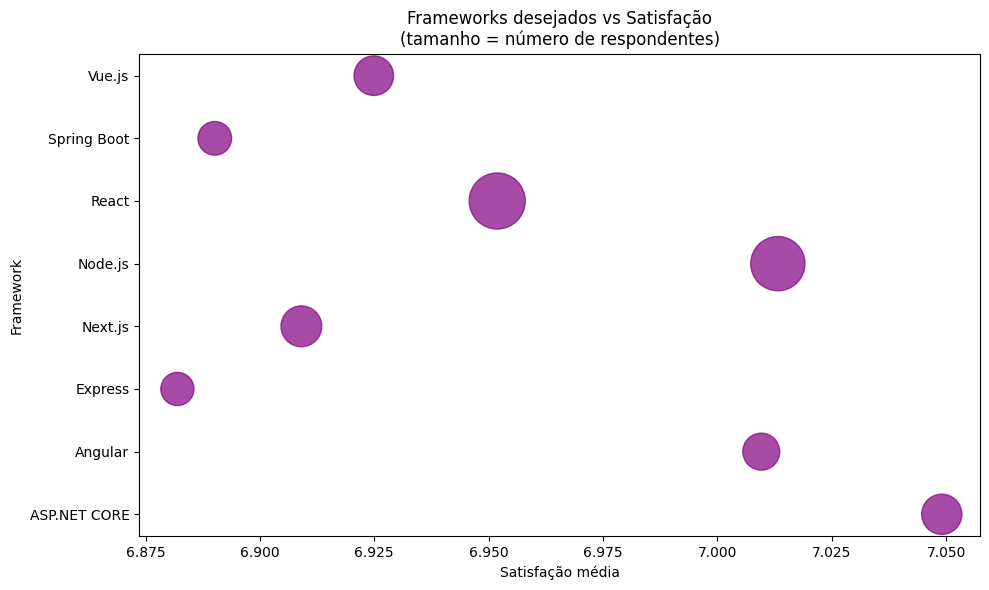

In [9]:
df_web = df[['WebframeWantToWorkWith', 'JobSat']].dropna()
df_web = df_web.assign(
    Framework=df_web['WebframeWantToWorkWith'].str.split(';')
).explode('Framework')
df_web['Framework'] = df_web['Framework'].str.strip()

top_fw = df_web['Framework'].value_counts().head(8).index
df_web = df_web[df_web['Framework'].isin(top_fw)]

fw_sat = df_web.groupby('Framework').agg(
    MeanSat=('JobSat', 'mean'),
    Count=('JobSat', 'count')
).reset_index()

plt.figure(figsize=(10, 6))
plt.scatter(
    fw_sat['MeanSat'],
    fw_sat['Framework'],
    s=fw_sat['Count'] / 5,
    alpha=0.7,
    color='purple'
)
plt.title('Frameworks desejados vs Satisfação\n(tamanho = número de respondentes)')
plt.xlabel('Satisfação média')
plt.ylabel('Framework')
plt.tight_layout()
plt.show()

#### 2. Bubble Plot for Admired Technologies Across Countries

- Visualize the distribution of admired technologies (`LanguageAdmired`) across different countries (`Country`).

- Use bubble size to represent the frequency of admiration.



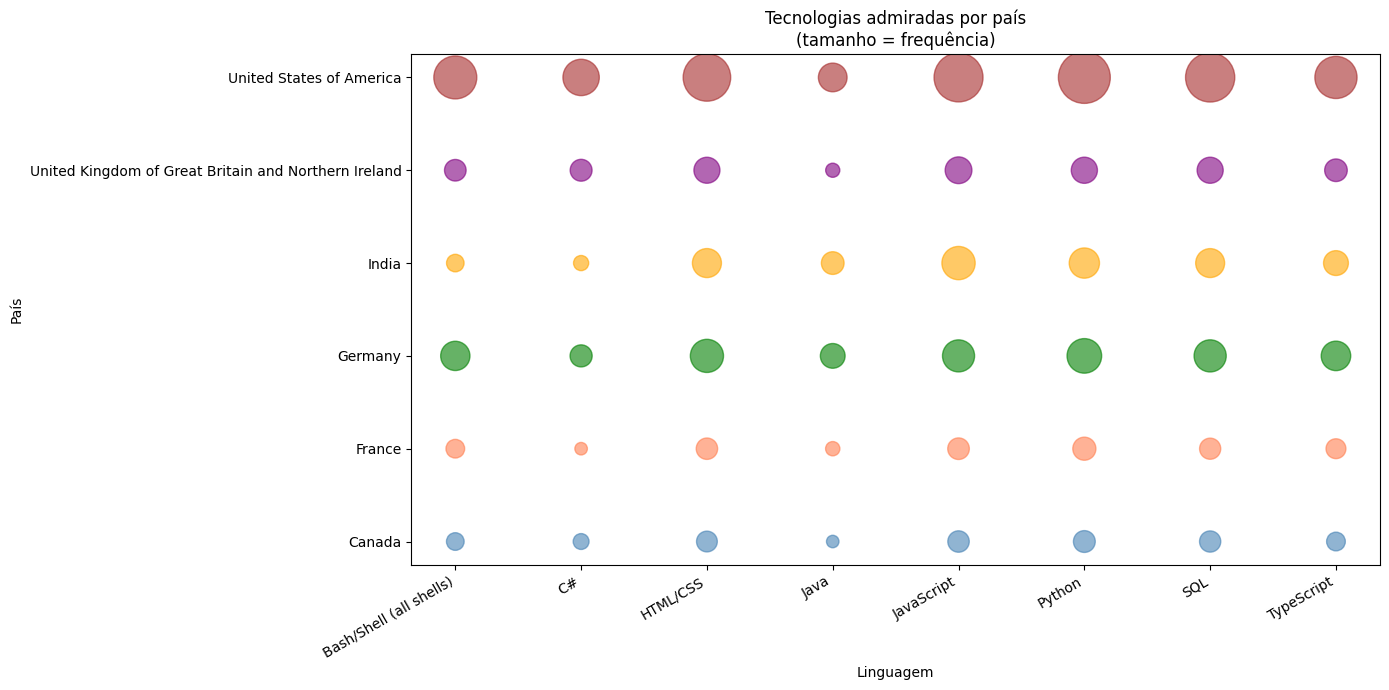

In [10]:
df_adm = df[['LanguageAdmired', 'Country']].dropna()
df_adm = df_adm.assign(
    Language=df_adm['LanguageAdmired'].str.split(';')
).explode('Language')
df_adm['Language'] = df_adm['Language'].str.strip()

top_langs = df_adm['Language'].value_counts().head(8).index
top_countries = df_adm['Country'].value_counts().head(6).index

df_adm = df_adm[
    df_adm['Language'].isin(top_langs) & 
    df_adm['Country'].isin(top_countries)
]

adm_country = df_adm.groupby(['Language', 'Country']).size().reset_index(name='Count')

plt.figure(figsize=(14, 7))
countries = adm_country['Country'].unique()
colors = ['steelblue', 'coral', 'green', 'orange', 'purple', 'brown']

for country, color in zip(countries, colors):
    subset = adm_country[adm_country['Country'] == country]
    plt.scatter(
        subset['Language'],
        [country] * len(subset),
        s=subset['Count'] / 3,
        alpha=0.6,
        color=color,
        label=country
    )

plt.title('Tecnologias admiradas por país\n(tamanho = frequência)')
plt.xlabel('Linguagem')
plt.ylabel('País')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## Final Step: Review


After completing the lab, you will have extensively used bubble plots to gain insights into developer community preferences, demographics, compensation trends, and job satisfaction.


## Summary


After completing this lab, you will be able to:

- Create and interpret bubble plots to analyze relationships and compositions within datasets.

- Use bubble plots to explore developer preferences, compensation trends, and satisfaction levels.

- Apply bubble plots to visualize complex relationships involving multiple dimensions effectively.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-29|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
